<a href="https://colab.research.google.com/github/aruna-31/Deep-Learning-practice-and-basic-projects/blob/main/002_Implementing_a_Custom_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import libraries and dataset
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# We will be using make_circles from scikit-learn
from sklearn.datasets import make_circles

SEED = 2025

In [ ]:
# First, we need to create the training data
# We create an inner and outer circle

X, y = make_circles(n_samples=400, factor=.3, noise=.05, random_state=2017)
outer = y == 0
inner = y == 1

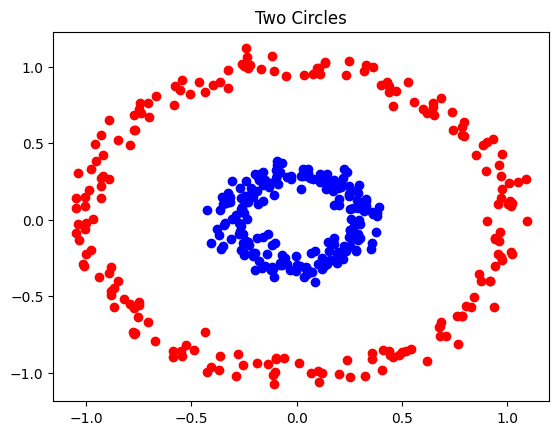

In [ ]:
# Let's plot the data to show the two classes

plt.title("Two Circles")
plt.plot(X[outer, 0], X[outer, 1], "ro")
plt.plot(X[inner, 0], X[inner, 1], "bo")
plt.show()

# Example of non-linearly separable data

In [ ]:
# We normalize the data to make sure the center of both circles is (1,1)

X = X+1

In [ ]:
# To determine the performance of our algorithm we split our data

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=SEED)

In [ ]:
# A linear activation function won't work in this case, so we'll be using a sigmoid function

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [ ]:
# Next, we define the hyperparameters

n_hidden = 50 # number of hidden units
n_epochs = 1000
learning_rate = 1

In [ ]:
# Initialize the weights and other variables

# Initialise weights
weights_hidden = np.random.normal(0.0, size=(X_train.shape[1], n_hidden))
weights_output = np.random.normal(0.0, size=(n_hidden))

hist_loss = []
hist_accuracy = []
print(weights_hidden)
print(weights_output)

[[-0.50404221  0.00424242  0.30769248 -0.53830604 -1.41935567 -0.21256059
  -1.32115125  1.1992569   0.69696387  0.87750576 -0.48018074 -0.1417767
   0.49884411 -0.59406209  0.43056038  0.35903184  1.66793103 -0.2148838
   0.46603088  0.94415678 -1.56499489  0.26318257 -1.41244043 -0.50126019
   0.18205325 -0.84750372  0.03118661  1.83046683  0.48033379 -1.19262661
   1.88458154 -0.09002404  0.07073403  2.23556513  0.95815895 -2.65028665
  -0.41648859  0.22767523 -0.57982155 -1.01744588 -0.68840123 -0.59514461
  -1.95955871  0.27468365  0.32823677 -0.54528828 -1.46192243  0.0228316
   1.39375504 -2.23096323]
 [ 0.30641502 -0.30042164 -0.89963244 -0.34471672  1.2355869  -0.10778388
  -1.18700807  0.48233334 -0.18962268  0.9176544   2.00809074 -0.02366637
  -0.75821805  1.72223548  2.23594673 -0.73420142 -0.11822907  0.09499997
  -0.16194923  0.04048481  0.7854042  -1.58215548  0.02662449  0.27572683
   0.70237888  0.09612942  1.49510659  0.35736209  0.19578022 -0.11946758
  -0.10414509 

In [ ]:
# Run the single-layer neural network and output the statistics

for e in range(n_epochs):
    del_w_hidden = np.zeros(weights_hidden.shape)
    del_w_output = np.zeros(weights_output.shape)

    # Loop through training data in batches of 1
    for x_, y_ in zip(X_train, y_train):
        # Forward computations
        hidden_input = np.dot(x_, weights_hidden)
        hidden_output = sigmoid(hidden_input)
        output = sigmoid(np.dot(hidden_output, weights_output))

        # Backward computations
        error = y_ - output
        output_error = error * output * (1 - output)
        hidden_error = np.dot(output_error, weights_output) * hidden_output * (1 - hidden_output)
        del_w_output += output_error * hidden_output
        del_w_hidden += hidden_error * x_[:, None]

    # Update weights
    weights_hidden += learning_rate * del_w_hidden / X_train.shape[0]
    weights_output += learning_rate * del_w_output / X_train.shape[0]

    # Print stats (validation loss and accuracy)
    if e % 100 == 0:
        hidden_output = sigmoid(np.dot(X_val, weights_hidden))
        out = sigmoid(np.dot(hidden_output, weights_output))
        loss = np.mean((out - y_val) ** 2)
        # Final prediction is based on a threshold of 0.5
        predictions = out > 0.5
        accuracy = np.mean(predictions == y_val)
        print("Epoch: ", '{:>4}'.format(e),
            "; Validation loss: ", '{:>6}'.format(loss.round(4)),
            "; Validation accuracy: ", '{:>6}'.format(accuracy.round(4)))

Epoch:     0 ; Validation loss:  0.5589 ; Validation accuracy:  0.4375
Epoch:   100 ; Validation loss:  0.2248 ; Validation accuracy:   0.625
Epoch:   200 ; Validation loss:  0.1859 ; Validation accuracy:  0.9125
Epoch:   300 ; Validation loss:  0.1527 ; Validation accuracy:    0.95
Epoch:   400 ; Validation loss:  0.1264 ; Validation accuracy:  0.9625
Epoch:   500 ; Validation loss:  0.1061 ; Validation accuracy:  0.9625
Epoch:   600 ; Validation loss:  0.0906 ; Validation accuracy:     1.0
Epoch:   700 ; Validation loss:  0.0786 ; Validation accuracy:     1.0
Epoch:   800 ; Validation loss:  0.0692 ; Validation accuracy:     1.0
Epoch:   900 ; Validation loss:  0.0617 ; Validation accuracy:     1.0
